# Histogram Backprojection

## Step 1: defining histogram generation functions

In [312]:
import numpy as np
from PIL import Image
import ipyplot

def generate_normalized_histogram(img, buckets):
    """
        Compute normalized histogram for image
        Args:
            img (nd.array(m, n,3)) Input image array of pixels with rgb values
            buckets scalar: Number of buckets to split each r,g,b value into
        Returns:
            normalized_histogram (nd.array(buckets/bucket,))
    """

    m = img.shape[0] * img.shape[1] * 3
    size_bucket = buckets // buckets
    
    normalized_histogram = np.zeros((3,buckets))

    # reshaping for easier iter
    for r, g, b in img.reshape(img.shape[0] * img.shape[1], 3):
        normalized_histogram[0][min(int(r/size_bucket), buckets - 1)] += 1 / m
        normalized_histogram[1][min(int(g/size_bucket), buckets - 1)] += 1 / m
        normalized_histogram[2][min(int(b/size_bucket), buckets - 1)] += 1 / m
    return normalized_histogram


In [313]:
def to_bw(img):
    """
        Converts color image to greyscale by averaging rgb
        Args:
            img (nd.array(m,n,3)): Input image
        Returns:
            bw_image (nd.array(m,n,3)): BW image
    """
    m = img.shape[0]
    n = img.shape[1]

    res = np.zeros((m, n, 3))
    for i in range(m):
        for j in range(n):
            s = np.sum(img[i][j]) / 3
            res[i][j] = (s, s, s)
    return res


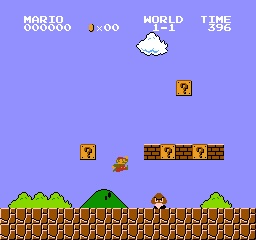


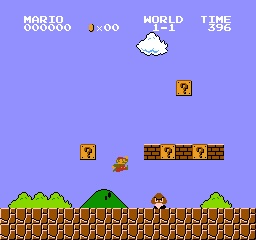

In [314]:


target_image = np.array(Image.open('../images/histogram-backprojection/StompThatGoombaNES.jpg'))
#model_image = target_image[155: 175, 110:130, :]
model_image = target_image[190: 210, 150:170, :]
ipyplot.plot_images([target_image], img_width = 400)
ipyplot.plot_images([model_image], img_width = 200)


In [ ]:
def get_bucket(i, buckets):
    return min(int(i / (buckets // buckets)), buckets - 1)




def compute_histogram_backprojection(model_image, target_image, buckets, bw=False):
    c = 3
    if bw:
        model_image = to_bw(model_image)
        target_image = to_bw(target_image)
        c = 1
    
    model_histogram = generate_normalized_histogram(model_image, buckets)
    target_histogram = generate_normalized_histogram(target_image, buckets)
    res = np.zeros((target_image.shape[0], target_image.shape[1], 3))
    
    for i in range(target_image.shape[0]):
        for j in range(target_image.shape[1]):

            r = get_bucket(target_image[i][j][0], buckets)
            g = get_bucket(target_image[i][j][1], buckets)
            b = get_bucket(target_image[i][j][2], buckets)
            red = min(model_histogram[0][r] / (target_histogram[0][r] + 0.0000001), 1)
            green = min(model_histogram[1][g]/ (target_histogram[1][g] + 0.0000001), 1)
            blue = min(model_histogram[2][b] / (target_histogram[2][b] + 0.0000001), 1)
            intensity = (red + green + blue) / 3
            res[i][j] = (intensity, intensity, intensity)
    return res



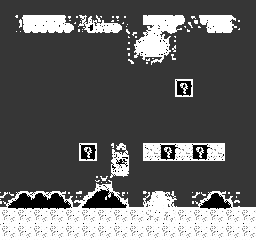


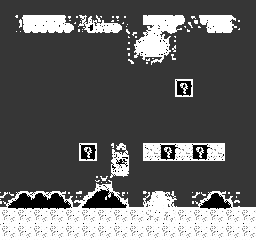

In [331]:
res = compute_histogram_backprojection(model_image, target_image, 200, True)
ipyplot.plot_images([res], img_width=500)


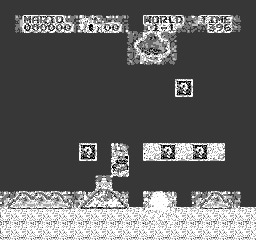


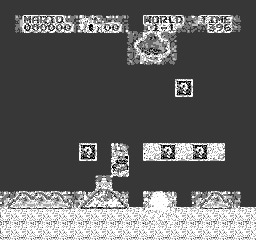

In [329]:
res = compute_histogram_backprojection(model_image, target_image, 255)
ipyplot.plot_images([res], img_width=500)